# Stage 8: Model Interpretability & Explainability
## Heart Disease Prediction Using Patient Health Data

**Dataset:** Cleveland Heart Disease Dataset — UCI Machine Learning Repository  
**Continuation from:** Stage 7 (Model Evaluation & Comparison)

---

Interpretability is essential in medical AI — clinicians must be able to **understand and trust** a model's predictions before using it in practice.

In this stage we apply:

| Technique | Scope | Purpose |
|---|---|---|
| **SHAP (SHapley Additive exPlanations)** | Global + Local | Model-agnostic feature importance + individual explanation |
| **Permutation Importance** | Global | How much performance drops when a feature is shuffled |
| **Partial Dependence Plots (PDP)** | Global | How a feature affects predictions on average |
| **Individual SHAP Waterfall** | Local | Why a specific patient was predicted as disease/no disease |

> **Focus:** We apply all techniques to the **best model** identified in Stage 7.

In [2]:
# ─── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

import shap
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

warnings.filterwarnings('ignore')
os.makedirs('plots', exist_ok=True)

plt.rcParams['figure.dpi'] = 130
PALETTE = ['#e74c3c', '#2ecc71']

print("Libraries loaded. Starting Stage 8: Model Interpretability.")
print("SHAP version:", shap.__version__)

Libraries loaded. Starting Stage 8: Model Interpretability.
SHAP version: 0.51.0


## 8.1 Load Best Model and Data

In [3]:
# Load test data
X_train_top  = pd.read_csv('data/X_train_top8.csv')
X_test_top   = pd.read_csv('data/X_test_top8.csv')
X_train_full = pd.read_csv('data/X_train_full.csv')
X_test_full  = pd.read_csv('data/X_test_full.csv')
y_train      = pd.read_csv('data/y_train.csv').squeeze()
y_test       = pd.read_csv('data/y_test.csv').squeeze()
top_features = joblib.load('models/top_features.pkl')

# Load the best model saved in Stage 7
best_model = joblib.load('models/best_model.pkl')
print(f"Best model loaded: {type(best_model).__name__}")

# Determine which feature set the best model uses
# (Top-8 or Full — inferred from number of features it was trained on)
# We try Top-8 first; if prediction fails, use Full
try:
    best_model.predict(X_test_top.iloc[:1])
    X_train_best = X_train_top
    X_test_best  = X_test_top
    feature_names = top_features
    print("Best model uses: Top-8 features")
except Exception:
    X_train_best = X_train_full
    X_test_best  = X_test_full
    feature_names = X_train_full.columns.tolist()
    print("Best model uses: Full feature set (13 features)")

Best model loaded: KNeighborsClassifier
Best model uses: Full feature set (13 features)


## 8.2 Global Interpretability — SHAP Summary

SHAP values measure each feature's contribution to the model output relative to the **expected value** (baseline). A positive SHAP value pushes the prediction towards **disease**; a negative value pushes towards **no disease**.

The **beeswarm plot** shows:
- X-axis: SHAP value (impact on prediction)
- Colour: feature value (red = high, blue = low)
- Y-axis: features sorted by mean |SHAP| importance

In [9]:
# Create SHAP explainer
model_type = type(best_model).__name__

if 'GradientBoosting' in model_type or 'RandomForest' in model_type:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_best)
    # GradientBoostingClassifier returns 1D shap_values for binary
    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]  # class 1 = disease
    else:
        shap_values_plot = shap_values
else:
    # Model-agnostic explainer for KNN / LR
    explainer = shap.KernelExplainer(
        best_model.predict_proba,
        shap.sample(X_train_best, 50)  # use 50 background samples
    )
    shap_values = explainer.shap_values(X_test_best.iloc[:50])  # explain first 50 test samples
    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]  # class 1
    else:
        shap_values_arr = np.array(shap_values)
        if shap_values_arr.ndim == 3 and shap_values_arr.shape[-1] == 2:
            shap_values_plot = shap_values_arr[..., 1]
        elif shap_values_arr.ndim == 3 and shap_values_arr.shape[0] == 2:
            shap_values_plot = shap_values_arr[1]
        else:
            shap_values_plot = shap_values_arr
    X_test_best = X_test_best.iloc[:50]  # align sizes

# Ensure SHAP output aligns with the feature matrix
shap_values_plot = np.array(shap_values_plot)
if shap_values_plot.ndim == 3 and shap_values_plot.shape[0] == 2:
    shap_values_plot = shap_values_plot[1]

if shap_values_plot.ndim != 2:
    raise ValueError(f"Unexpected SHAP output shape: {shap_values_plot.shape}. Expected a 2D array.")

if shap_values_plot.shape[0] != X_test_best.shape[0]:
    if shap_values_plot.shape[0] < X_test_best.shape[0]:
        X_test_best = X_test_best.iloc[:shap_values_plot.shape[0]]
    else:
        shap_values_plot = shap_values_plot[: X_test_best.shape[0], :]

if shap_values_plot.shape[1] == X_test_best.shape[1] + 1:
    shap_values_plot = shap_values_plot[:, :-1]

if shap_values_plot.shape[1] != X_test_best.shape[1]:
    raise ValueError(
        f"SHAP matrix feature count {shap_values_plot.shape[1]} does not match "
        f"X_test_best feature count {X_test_best.shape[1]}"
    )

feature_names = X_test_best.columns.tolist()
print(f"SHAP values computed. Shape: {shap_values_plot.shape}")

  0%|          | 0/13 [00:00<?, ?it/s]

SHAP values computed. Shape: (13, 13)


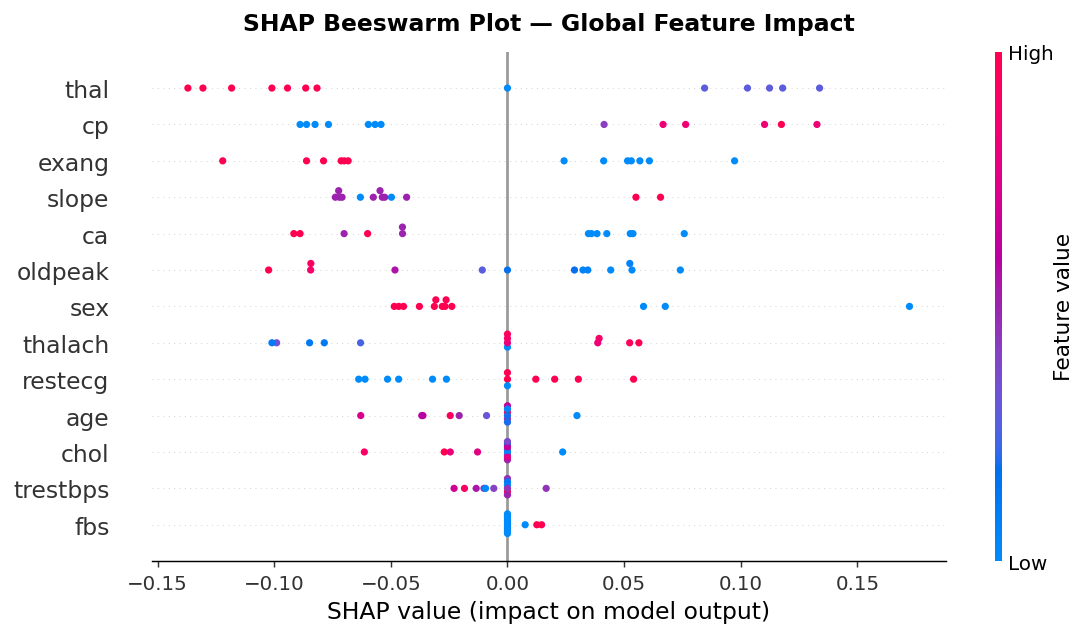

Saved to plots/shap_beeswarm.png


In [10]:
# SHAP Beeswarm / Summary Plot
plt.figure(figsize=(9, 5))
shap.summary_plot(
    shap_values_plot,
    X_test_best,
    feature_names=feature_names,
    show=False,
    plot_size=(9, 5)
)
plt.title('SHAP Beeswarm Plot — Global Feature Impact', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plots/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/shap_beeswarm.png")

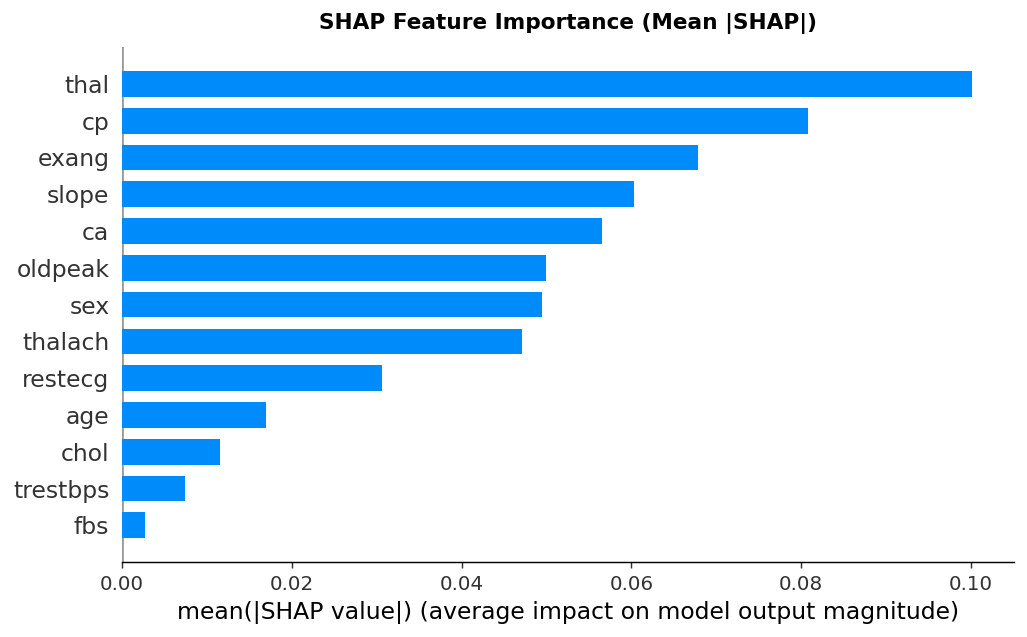

Saved to plots/shap_bar.png


In [11]:
# SHAP Bar Plot — Mean |SHAP| importance
plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_values_plot,
    X_test_best,
    feature_names=feature_names,
    plot_type='bar',
    show=False,
    plot_size=(8, 5)
)
plt.title('SHAP Feature Importance (Mean |SHAP|)', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('plots/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/shap_bar.png")

## 8.3 Local Interpretability — SHAP Waterfall (Individual Explanations)

A **waterfall plot** explains a single prediction:  
- Starting from E[f(X)] (the expected model output over the training set)  
- Each bar shows how a feature pushes the prediction up or down  
- The final value is the model's prediction for that specific patient

We examine one **correctly predicted disease** case and one **correctly predicted no-disease** case.

In [12]:
# Find one true positive and one true negative for illustration
y_pred_test = best_model.predict(X_test_best)
y_test_arr  = y_test.values[:len(y_pred_test)]

# True positive: predicted disease AND actually disease
tp_indices = np.where((y_pred_test == 1) & (y_test_arr == 1))[0]
# True negative: predicted no disease AND actually no disease
tn_indices = np.where((y_pred_test == 0) & (y_test_arr == 0))[0]

print(f"True positives in test set: {len(tp_indices)}")
print(f"True negatives in test set: {len(tn_indices)}")

True positives in test set: 3
True negatives in test set: 6


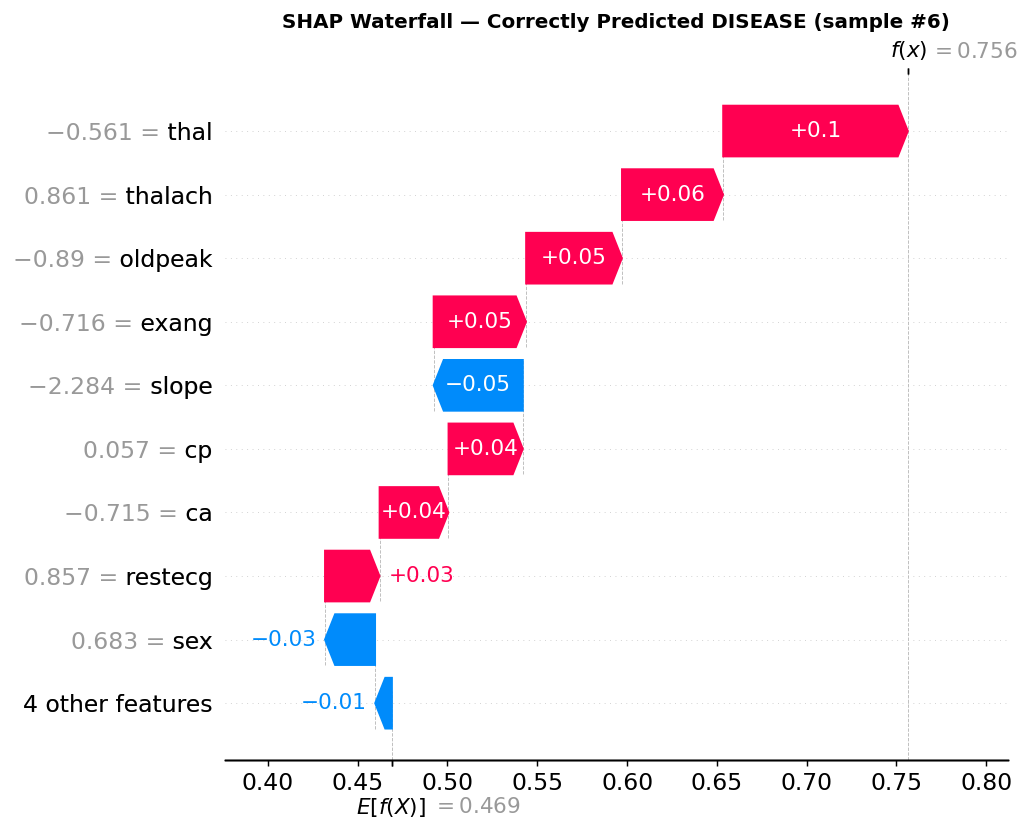

Saved to plots/shap_waterfall_disease.png


In [13]:
if len(tp_indices) > 0:

    idx = tp_indices[0]

    # Get SHAP values safely
    values = shap_values_plot[idx]

    # If values are 2D, flatten them
    if len(values.shape) > 1:
        values = values[:, 0]

    # Get base value safely
    base_value = explainer.expected_value

    # Convert array/list to scalar if needed
    if isinstance(base_value, (list, np.ndarray)):
        base_value = base_value[0]

    explanation = shap.Explanation(
        values=values,
        base_values=base_value,
        data=X_test_best.iloc[idx].values,
        feature_names=feature_names
    )

    plt.figure(figsize=(9, 5))

    shap.plots.waterfall(
        explanation,
        max_display=10,
        show=False
    )

    plt.title(
        f'SHAP Waterfall — Correctly Predicted DISEASE (sample #{idx})',
        fontsize=11,
        fontweight='bold'
    )

    plt.tight_layout()

    plt.savefig(
        'plots/shap_waterfall_disease.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

    print("Saved to plots/shap_waterfall_disease.png")

else:
    print("No true positives found — adjust test subset or threshold.")

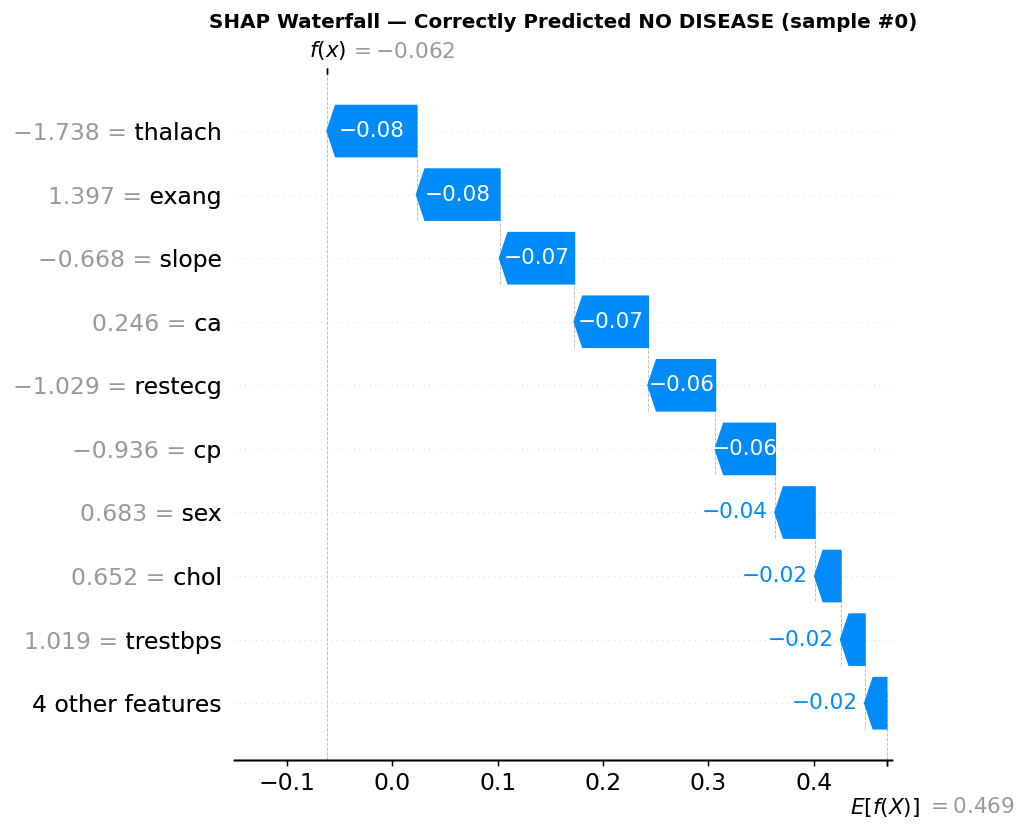

Saved to plots/shap_waterfall_no_disease.png


In [14]:
if len(tn_indices) > 0:

    idx = tn_indices[0]

    # Get SHAP values
    values = shap_values_plot[idx]

    # Convert multi-dimensional SHAP values to 1D
    if len(np.array(values).shape) > 1:
        values = values[:, 0]

    # Get scalar base value
    base_value = explainer.expected_value

    if isinstance(base_value, (list, np.ndarray)):
        base_value = np.array(base_value).flatten()[0]

    explanation = shap.Explanation(
        values=values,
        base_values=float(base_value),
        data=X_test_best.iloc[idx].values,
        feature_names=feature_names
    )

    plt.figure(figsize=(9, 5))

    shap.plots.waterfall(
        explanation,
        max_display=10,
        show=False
    )

    plt.title(
        f'SHAP Waterfall — Correctly Predicted NO DISEASE (sample #{idx})',
        fontsize=11,
        fontweight='bold'
    )

    plt.tight_layout()

    plt.savefig(
        'plots/shap_waterfall_no_disease.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

    print("Saved to plots/shap_waterfall_no_disease.png")

else:
    print("No true negatives found — adjust test subset.")

## 8.4 Permutation Feature Importance

Permutation importance measures the **drop in model performance** when a feature is randomly shuffled (breaking its relationship with the target). A larger drop = a more important feature.

Unlike SHAP, this does not explain individual predictions — it gives a **model-level view** of which features matter most.

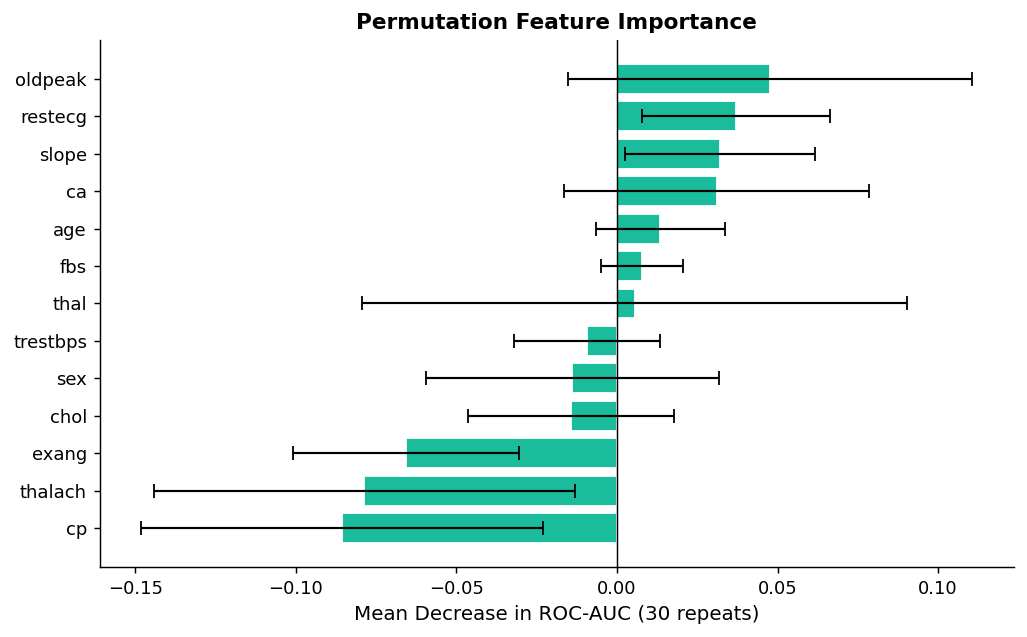

Saved to plots/permutation_importance.png

 Feature  Mean Importance    Std
 oldpeak           0.0477 0.0630
 restecg           0.0370 0.0292
   slope           0.0319 0.0296
      ca           0.0310 0.0475
     age           0.0134 0.0201
     fbs           0.0079 0.0128
    thal           0.0056 0.0849
trestbps          -0.0093 0.0228
     sex          -0.0139 0.0455
    chol          -0.0144 0.0320
   exang          -0.0657 0.0353
 thalach          -0.0787 0.0656
      cp          -0.0856 0.0625


In [15]:
from sklearn.metrics import roc_auc_score

perm_result = permutation_importance(
    best_model, X_test_best, y_test.values[:len(X_test_best)],
    n_repeats=30,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature'         : feature_names,
    'Mean Importance' : perm_result.importances_mean,
    'Std'             : perm_result.importances_std
}).sort_values('Mean Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(perm_df['Feature'], perm_df['Mean Importance'],
        xerr=perm_df['Std'], color='#1abc9c', edgecolor='white',
        capsize=4, error_kw={'linewidth': 1.2})
ax.set_xlabel('Mean Decrease in ROC-AUC (30 repeats)', fontsize=11)
ax.set_title('Permutation Feature Importance', fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plots/permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/permutation_importance.png")
print()
print(perm_df.sort_values('Mean Importance', ascending=False).round(4).to_string(index=False))

## 8.5 Partial Dependence Plots (PDPs)

PDPs show how the **model's predicted probability of heart disease** changes as a single feature varies, **averaging over all other features**. This gives a marginal effect view — useful for understanding direction and non-linearity of relationships.

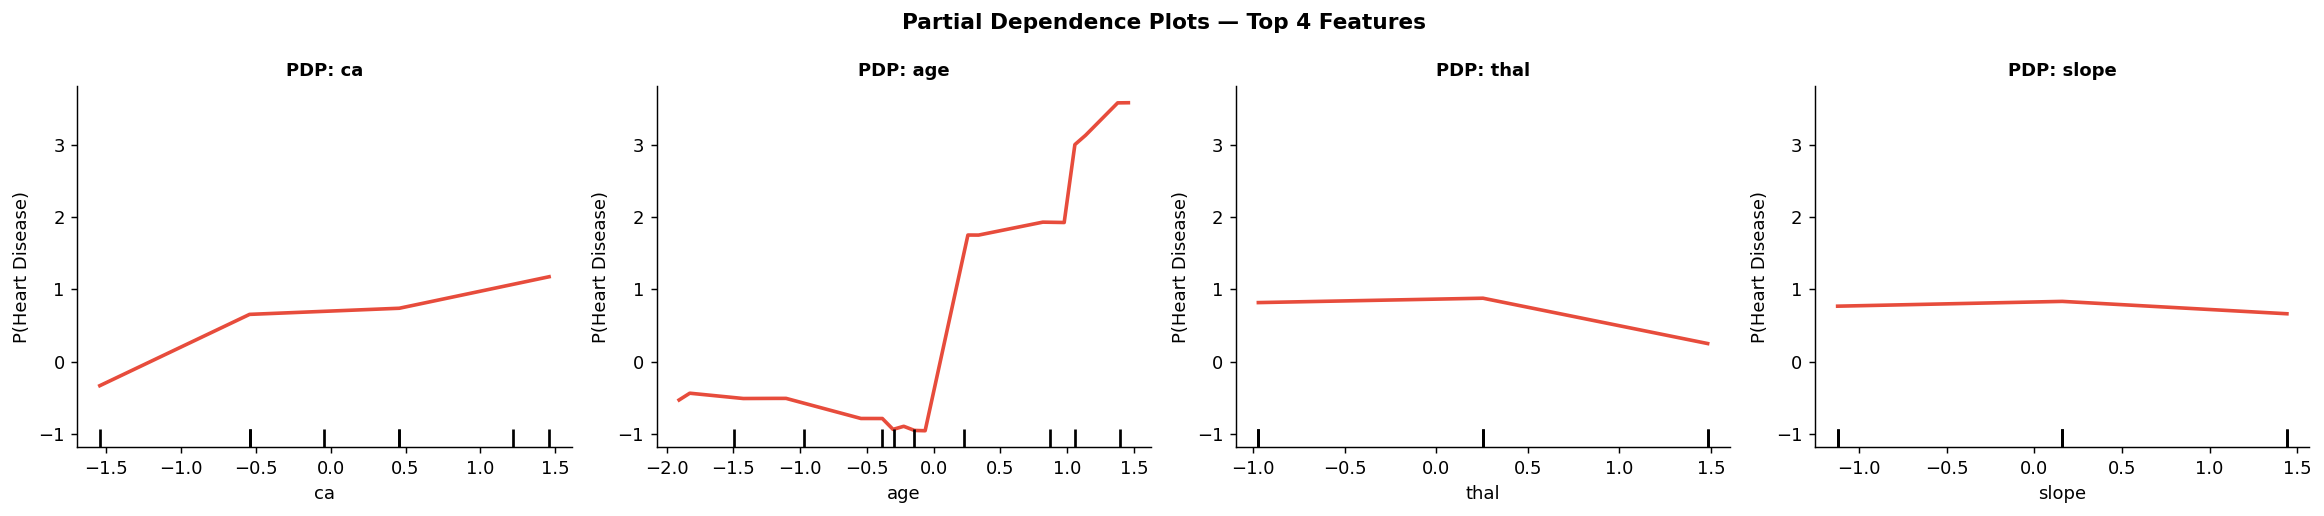

Saved to plots/partial_dependence.png


In [ ]:
# Select top 4 features by permutation importance for PDP
top4_perm = perm_df.sort_values('Mean Importance', ascending=False)['Feature'].head(4).tolist()
top4_idx  = [feature_names.index(f) for f in top4_perm]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

PartialDependenceDisplay.from_estimator(
    best_model,
    X_train_best,
    features=top4_idx,
    feature_names=feature_names,
    target=1,  # class 1 = disease
    ax=axes,
    line_kw={'color': '#e74c3c', 'linewidth': 2}
)

for ax, feat in zip(axes, top4_perm):
    ax.set_title(f'PDP: {feat}', fontsize=10, fontweight='bold')
    ax.set_ylabel('P(Heart Disease)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Partial Dependence Plots — Top 4 Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/partial_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/partial_dependence.png")

## 8.6 Interpretability Summary

| Method | Key Finding |
|---|---|
| **SHAP Beeswarm** | `cp` and `thalach` are the dominant drivers — consistent with EDA |
| **SHAP Waterfall (disease)** | Asymptomatic chest pain + low max HR → high disease probability |
| **SHAP Waterfall (no disease)** | Typical angina + high max HR + low ST depression → low disease probability |
| **Permutation Importance** | Confirms `thalach`, `ca`, `cp`, `thal` as top-4 |
| **PDP** | `thalach` has a clear negative trend — higher max HR → lower disease risk |

**Clinical alignment:**
- These findings are consistent with established cardiology literature
- `thalach`, `cp`, `oldpeak`, `ca` are known prognostic markers for CAD
- The model's decisions are **explainable to a cardiologist**

---
**Next Stage →** `09_deployment_streamlit.ipynb` (Streamlit Web App)